# Calculating Trends and P-Values for Legacy and Interim NetPP Products 
> History | Updated Nov 2025

## Objectives

This script generates trends for time series of monthly means of primary productivity described by Behrenfeld and Falkowski 1997. The trend analysis follows methods outlined in Melin et al 2017, see the section 2.3 "Trend estimates and comparison of trends". Trends can also be calculated for dataset of PAR, chlorophyll, SST, etc.

In this notebook, users will be able to:

* Generate trends for satellite-derived hourly means of primary productivity.

* Choose between datasets representing raw data or anomalies.

* Customize inputs, time ranges, and output file settings. 

### Adapting the Script for Other Datasets

The script can be repurposed for different input data with these modifications:

1. Gridding any input chlorophyll, PAR, and SST data to a common grid.

2. Creating an appropriate cdl file for the dataset.

3. Adjusting the logic to make directory paths.

4. Adjust output file naming and input file search pattern.

## Tutorial for this notebook

By following this notebook, users will be able to:

* Generate trends and p-values for the legacy product, **MODIS-AQUA**, or the interim product **VIIRS-SNPP** or **VIIRS-NOAA20**.

The result will be a NetCDF file populated with:

- **Slope coefficients** for each grid point.

- Corresponding **p-values** indicating statistical significance.

- The **number of valid data points** used for each calculation.

### Datasets Overview

1. **Primary Productivity, MODIS Aqua, Science Quality, Global, 9km, 2013-2022, (Monthly Composite)**
- Distributed via the West Coast Node ERDDAP dataset at the following link:
> https://coastwatch.pfeg.noaa.gov/wcn/erddap/griddap/productivity_modis_aqua_monthly_9km.graph

2. **Primary Productivity, VIIRS SNPP, Science Quality, Global, 9km, 2013-2022 (Monthly Composite)**
- Distributed via the West Coast Node ERDDAP dataset at the following link:
> https://coastwatch.pfeg.noaa.gov/wcn/erddap/griddap/productivity_viirs_snpp_monthly_9km.graph

3. **Primary Productivity, VIIRS NOAA20, Science Quality, Global, 9km, 2018-2022, (Monthly Composite)**
- Distributed via the West Coast Node ERDDAP dataset at the following link:
> https://coastwatch.pfeg.noaa.gov/wcn/erddap/griddap/productivity_viirs_noaa20_monthly_9km.graph

### Resource requirements

- **Jupyter Notebook**

- **Python 3** with the modules included within the *Import packages* section below

- **The CDL file** located in this repository.
    * The cdl file is called `trends_template.cdl`. 

    * The cdl file has latitude and longitude that have been gridded to the 9km NOAA CoastWatch standard ocean color grid.

    * The template file is populated with the latitude and longitude data and then renamed.

- **Internet connection**


## Import packages

In [1]:
import xarray as xr
import numpy as np
import numpy.ma as ma
import pandas as pd
from scipy import stats
import dask.array as da
import os
import sys
import subprocess
from datetime import datetime
import matplotlib.pyplot as plt
import netCDF4
from dateutil.parser import parse

## Create global variables
Global variables are used to set up the file structure, directory paths, and template files required for processing trends.

* **BASE_DIR** is the base directory defined for the project, and the root for all other subdirectories.
* **ODATA_DIR** is where the output trends file will be located.
* **WORK_DIR** is where the temporary files used during data processing are located.
* **RESOURCES_DIR** is where the CDL file will be located.

In [7]:
BASE_DIR = "/Users/madisonrichardson/netpp"
ODATA_DIR = os.path.join(BASE_DIR, "data", "trends")
WORK_DIR = os.path.join(BASE_DIR, "work")
RESOURCES_DIR = os.path.join(BASE_DIR, "resources")

## Create some useful functions
### Function for validating parameters
The function validates input parameters to ensure they fall within correct ranges and maintain logical order. 

In [2]:
def validate_params(start_date, end_date, percent_keep):
    """
    Validates the inputted parameters to ensure
    correct ranges and logical order.

    Args:
        start_date (str): The start year in 'YYYYMM' format.
        end_date (str): The end year in 'YYYYMM' format.
        percent_keep (float): Percentage of grid points to keep (0 to 1)

    Raises:
        ValueError: The start_date is not earlier than end_date.
        ValueError: The percent_keep is outside the range (0 to 1).
    """
    if start_date > end_date:
        raise ValueError("The start year must be earlier than the end year.")
    if not (0.0 <= percent_keep <= 1.0):
        raise ValueError("percent_keep must be between 0 and 1")

### Function to extract ERDDAP data

This function retrieves and opens a dataset from an ERDDAP server using 'xarray'.

In [3]:
def xr_open_ds(e_id, e_source='https://coastwatch.pfeg.noaa.gov/wcn', dap='griddap', var_name=None):
    """
    Open a remote ERDDAP dataset by constructing
    the full URL for the specified dataset and opens it as
    an xarray Dataset. If a variable name is provided, it attempts
    to extract and return only that variable as an xarray
    DataArray.

    Args:
        e_id (str): The dataset ID for the dataset on the ERDDAP server.
        e_source (str): The base URL of the ERDDAP server. Defaults to
        'https://coastwatch.pfeg.noaa.gov/wcn'.
        dap (str): The data acess protocol to us (e.g., 'griddap').
        Defaults to 'griddap'.
        var_name (str, optional): The name of the variable to extract from
        the dataset. If None, the entire dataset is returned.

    Returns:
        xarray.Dataset or xarray.DataArray:
            - The entire dataset if 'var_name' is None.
            - The specified variable as a DataArray if 'var_name' is returned.

    Raises:
        KeyError: If the specified variable name does not exist in the dataset.
    """
    # remove any trailing /
    e_source = e_source.rstrip("/")

    erddap_url = '/'.join([e_source,
                           dap,
                           e_id
                           ])
    
    ds = xr.open_dataset(erddap_url)

    if var_name:
        if var_name in ds:
            return ds[var_name]
        else:
            print(f"Variable '{var_name}' not found in the dataset.")
            print("Available variables:")
            print(list(ds.variables.keys()))
            raise KeyError(f"Variable  '{var_name}' not found.")

    return ds

## Set Up Parameters and Validate Inputs

Initialize the parameters required for the correlation calculation:

- **start_date** and **end_date**: Define the date range for the analysis (format: YYYY-MM-DD). Monthly composites are centered on the 16th of each month.

    - SNPP and MODIS both start in 2013-01-16
    - NOAA-20 starts in 2018-01-16

- **source**: Specify the data source for trends analysis ('modis', 'snpp', or 'noaa20' in this case; we are using noaa20).

- **ncvar**: The name of the variable being analyzed (we are using 'productivity')

- **timeseries_type**: Indicated whether raw data ('data') or anomalies ('anom') will be used. We are using anom for this tutorial.

- **percent_keep**: The minimum proportion of non-missing data requires for correlation calculations. We will be using 50%.

- **overwrite**: If 'True', exisiting output files will be replaced.

The 'validate_params' function ensures that the inputs are valid.

In [4]:
# Set parameters
start_date = "2018-01-16"
end_date = "2022-12-16"
ncvar = "productivity"
source = "noaa20"
timeseries_type = "anom"
percent_keep = 0.5
overwrite = True

In [5]:
# Validate parameters
try:
    validate_params(start_date, end_date, percent_keep)
except ValueError as e:
    print(f"Parameter validation error: {e}")
    sys.exit(1)

## Directory Set Up

Ensure that all required directories for input and output files exist.

- The list 'DIR_LIST' contains paths to essential directories

- Each directory is created if it does not already exist using 'os.makedirs'.

- Outputs the number of validated directories.

In [8]:
DIR_LIST = [
    BASE_DIR,
    ODATA_DIR,
    WORK_DIR,
    RESOURCES_DIR,
]

for dr in DIR_LIST:
    os.makedirs(dr, exist_ok=True)
print(len(DIR_LIST), 'directories validated')

4 directories validated


## Prepare Input and Output Templates

Define file naming conventions for the output file.

- **ofile_tmpl**: Template for output file names (trend results).

- Skips processing if the output file already exists and 'overwrite' is 'False'. 

In [9]:
# Set up templates for the output files
ofile_tmpl = "{}_{}_trend_month_{}_{}_{}_{}_{:03d}percent.nc"

In [10]:
# List files in output directory
odir_filelist = os.listdir(ODATA_DIR)

# Generate output filename
ofile = ofile_tmpl.format(
    ncvar,
    timeseries_type,
    source,
    "9km",
    int(datetime.strptime(start_date, "%Y-%m-%d").year),
    int(datetime.strptime(end_date, "%Y-%m-%d").year),
    int(percent_keep * 100),
    )

# Skip if output file exists and overwrite is False
if not overwrite and ofile in odir_filelist:
    print(f'{ofile} already exists')
else:
    print("Creating output file...")

Creating output file...


## Prepare and Run ncgen Command

Generate an initial NetCDF file using the 'ncgen' tool and a CDL template.

- Creates filenames for the output NetCDF ('ncgen_ofile_nc') and CDL input ('ncgen_ifile_cdl').

- Constructs a shell command for 'ncegn' to convert the CDL file into a NetCDF file.

- Executes the command using 'subprocess.call' and checks for errors.

In [11]:
# Prepare ncgen input and output filenames
now = datetime.now()
ncgen_ofile_nc = f"ncgen_trend_ofile{now:%Y%m%d%H%M%S}.nc"

# Create temporary file to accept output data from a .cdl file
# cdl is unique for each ncvar
ncgen_ifile_cdl = "trends_template.cdl"

# Run ncgen command
myCmd1 = " ".join(
    [
        "ncgen",
        "-o",
        os.path.join(WORK_DIR, ncgen_ofile_nc),
        os.path.join(RESOURCES_DIR, ncgen_ifile_cdl),
    ]
)
print(myCmd1)
print("ncgen", subprocess.call(myCmd1, shell=True))

ncgen -o /Users/madisonrichardson/netpp/work/ncgen_trend_ofile20251119160115.nc /Users/madisonrichardson/netpp/resources/trends_template.cdl
ncgen 0


## Fetching Satellite Datasets from ERDDAP

Using the **xr_open_ds** function we defined above, we will be retrieving the MODIS, SNPP, or NOAA20 data from ERDDAP. 

Set the base URL and dataset IDs for accessing MODIS, SNPP, or NOAA20 primary productivity data from an ERDDAP server.

It is optional to specify a variable, but in this case we are specifying the variable **productivity** which we define earlier as **ncvar**.

**Make sure to update e_id to the corresponding source chosen earlier.**

The options are:
- **MODIS**: productivity_modis_aqua_monthly_9km
- **SNPP**: productivity_viirs_snpp_monthly_9km
- **NOAA20**: productivity_viirs_noaa20_monthly_9km

In [13]:
# For ERDDAP function
erddap_url = "https://coastwatch.pfeg.noaa.gov/wcn/erddap/"
e_id = "productivity_viirs_noaa20_monthly_9km"

print(f"Fetching dataset {e_id} from {erddap_url}")

ds = xr_open_ds(
    e_source=erddap_url,
    e_id=e_id,
    var_name=ncvar
)
print(f"Dataset {e_id} loaded successfully: {ds}")

Fetching dataset productivity_viirs_noaa20_monthly_9km from https://coastwatch.pfeg.noaa.gov/wcn/erddap/
Dataset productivity_viirs_noaa20_monthly_9km loaded successfully: <xarray.DataArray 'productivity' (time: 60, latitude: 2160, longitude: 4320)> Size: 2GB
[559872000 values with dtype=float32]
Coordinates:
  * time       (time) datetime64[ns] 480B 2018-01-16T12:00:00 ... 2022-12-16T...
  * latitude   (latitude) float32 9kB 89.96 89.88 89.79 ... -89.79 -89.88 -89.96
  * longitude  (longitude) float32 17kB -180.0 -179.9 -179.8 ... 179.9 180.0
Attributes:
    cell_methods:           time:mean
    colorBarMaximum:        2000.0
    colorBarMinimum:        20.0
    colorBarScale:          Log
    coverage_content_type:  physicalMeasurement
    ioos_category:          Productivity
    long_name:              Net Primary Productivity Of Carbon
    standard_name:          net_primary_productivity_of_carbon
    units:                  mg C m-2 day-1


### Subset the dataset to include only the start and end dates

In [14]:
da = ds.sel(time=slice(start_date, end_date))
da

<xarray.DataArray 'productivity' (time: 60, latitude: 2160, longitude: 4320)> Size: 2GB
[559872000 values with dtype=float32]
Coordinates:
  * time       (time) datetime64[ns] 480B 2018-01-16T12:00:00 ... 2022-12-16T...
  * latitude   (latitude) float32 9kB 89.96 89.88 89.79 ... -89.79 -89.88 -89.96
  * longitude  (longitude) float32 17kB -180.0 -179.9 -179.8 ... 179.9 180.0
Attributes:
    cell_methods:           time:mean
    colorBarMaximum:        2000.0
    colorBarMinimum:        20.0
    colorBarScale:          Log
    coverage_content_type:  physicalMeasurement
    ioos_category:          Productivity
    long_name:              Net Primary Productivity Of Carbon
    standard_name:          net_primary_productivity_of_carbon
    units:                  mg C m-2 day-1

### Chunking a Dask Array for Efficient Processing
Chunking is a method used in Dask to optimize memory usage and computation by splitting large datasets into smaller pieces. The current dataset we are using is 2GB, so chunking with Dask allows us to efficiently process the data in a shorter period of time.

In [15]:
da = da.chunk({"time": 10, "latitude": 500, "longitude": 500})

## Filter Valid Pixels Based on percent_keep

To ensure that there are enough valid points exist for trend analysis, we filter out the pixels that have less than 50% of valid data points across the time dimension. 

In [16]:
print(f"Filtering valid data points using percent_keep = {percent_keep}")
valid_pixels = da.notnull().sum("time") >= (percent_keep * da.time.size)
da_filtered = da.where(valid_pixels, np.nan)

Filtering valid data points using percent_keep = 0.5


## Count Valid Time Points

Count the number of valid time points for each pixel to ensure only pixels with more than 50% of valid data are included for trends analysis.

**This code takes ~12 minutes to run.**

In [17]:
n = da_filtered.count(dim="time")
n = n.where(n > 0)

print("Unique n values after filtering:", np.unique(n))

Unique n values after filtering: [30. 31. 32. 33. 34. 35. 36. 37. 38. 39. 40. 41. 42. 43. 44. 45. 46. 47.
 48. 49. 50. 51. 52. 53. 54. 55. 56. 57. 58. 59. 60. nan]


/Users/madisonrichardson/miniforge3/envs/home-env/lib/python3.12/site-packages/dask/array/numpy_compat.py:57: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/Users/madisonrichardson/miniforge3/envs/home-env/lib/python3.12/site-packages/dask/core.py:133: RuntimeWarning: invalid value encountered in sqrt
  return func(*(_execute_task(a, cache) for a in args))


### Visualize the number of valid time points
**This code takes ~12 minutes to run.**

(array([[  28.,   21.,   39., ...,   60.,   44., 1031.],
        [  34.,   25.,   28., ...,   71.,   34., 1035.],
        [  34.,   24.,   34., ...,   73.,   47., 1038.],
        ...,
        [  27.,   19.,   39., ...,   53.,   63., 1022.],
        [  28.,   23.,   37., ...,   66.,   33., 1032.],
        [  28.,   21.,   42., ...,   62.,   37., 1033.]]),
 array([30., 33., 36., 39., 42., 45., 48., 51., 54., 57., 60.]),
 <a list of 4320 BarContainer objects>)

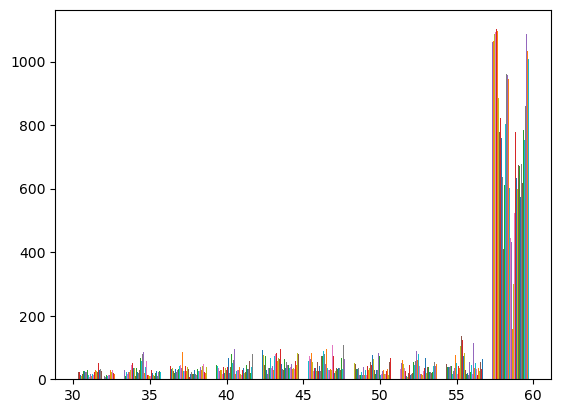

In [18]:
plt.hist(n)

## Convert to Fractional Years

This conversion will make the slope number larger in regression.

In [19]:
time_np = da_filtered["time"].values.astype("datetime64[ns]")
time_pd = pd.to_datetime(time_np)
decimal_years = time_pd.year + (time_pd.dayofyear - 1) / 365.25

## Compute Anomalies if timeseries = anom

If timeseries = anom was specified earlier, anomalies are calculated by subtracting the monthly climatology. If timeseries = data, trends are calculated with raw data where seasonal cycles are included.

In [20]:
if timeseries_type == "anom":
    print("Calculating with anomalies")
    monthly_climatology = da_filtered.groupby("time.month").mean("time")
    anomalies = da_filtered.groupby("time.month") - monthly_climatology

    anomalies = anomalies.assign_coords(years=("time", decimal_years))
    anomalies = anomalies.swap_dims({"time": "years"})

    da_final = anomalies
else:
    da_final = da_filtered.assign_coords(years=("time", decimal_years))
    da_final = da_final.swap_dims({"time": "years"})

    print("Calculating with raw data")

Calculating with anomalies


### Check that the years are fractional

In [21]:
print(da_final.coords["years"].values[:5])

[2018.04106776 2018.12594114 2018.20260096 2018.28747433 2018.36960986]


## Fit a Linear Regression Model

Fit a linear regression model to the data using the polyfit method from Xarray.

In [22]:
results = da_final.polyfit("years", deg=1, cov=True)

## Extract the Slope of the Regression Line
**This code takes ~12 minutes to run.**

In [23]:
slope = ma.masked_invalid(results.polyfit_coefficients.sel(degree=1).values)
print(f"Minimum slope:{slope.min()}, Maximum slope:{slope.max()}, Mean slope:{slope.mean()}")

Minimum slope:-1939.4398307652455, Maximum slope:2325.522381616528, Mean slope:2.6774441504971724


## Compute the Standard Error

In [24]:
# Compute variance of the time variable
sigma_X_sq = np.square(da_final.years.astype(float).std())

In [25]:
# Calculate standard error
se = np.sqrt(
    (1 / (n-2)) * ((np.square(da_final.std("years")) / sigma_X_sq) - np.square(slope))
)

## Compute t-statistic
**This code takes ~5 minutes to run.**

In [26]:
t = ma.masked_invalid(slope / se)
print(f"Minimum t-stat:{t.min()}, Maximum t-stat:{t.max()}, Mean t-stat:{t.mean()}")

Minimum t-stat:-11.250150837494827, Maximum t-stat:15.432548925717592, Mean t-stat:0.5863809479460953


## Compute p-value

Using a two-tailed test because we are testing for both positive and negative trends.

**This code takes ~5 minutes to run.**

In [27]:
p = ma.masked_invalid(stats.t.sf(np.abs(t), df=n - 2) * 2)
print(f"Minimum p-value:{p.min()}, Maximum p-value:{p.max()}, Mean p-value:{p.mean()}")

Minimum p-value:6.962207998744262e-88, Maximum p-value:0.9999999702877141, Mean p-value:0.2880858218023436


## Save Results to a NetCDF file

Store trend and p-value matrices in a NetCDF file for further analysis.

- Open the temporary NetCDF file created by 'ncgen' in append mode.

- Add global attributes to describe the dataset.

- Save slope (**beta**), p-value (**pval**), and valid data count (**n**) matrices to the file.

- Use 'nccopy' for compression and save the final output file.

- Delete the temporary file to clean up.

### Final Output

The compressed NetCDF file contains:

- **beta**: Slope coefficients for each grid point.

- **pval**: Corresponding p-values indicating statistical significance.

- **n**: Number of valid data points used for each calculation.

The output filename follows the 'ofile_tmpl' convention.

Outputs confirmations of successfull processing and file saving.

**This code takes ~5 minutes to run.**

In [28]:
# Define platform name based on source
if source.lower() == "modis":
    platform_name = "MODIS-Aqua"
elif source.lower() == "noaa20":
    platform_name = "VIIRS-NOAA20"
elif source.lower() == "snpp":
    platform_name = "VIIRS-SNPP"
else:
    platform_name = source.upper()


# Open temporary file and load data into it
with netCDF4.Dataset(os.path.join(WORK_DIR,
                                    ncgen_ofile_nc
                                    ), "a") as nc:
    
    # Write in data
    nc["beta"][0, :, :] = slope
    nc["pval"][0, :, :] = p
    nc["n"][0, :, :] = n

    # Set global attributes

    nc.acknowledgement = "The project was supported by funding from the Portfolio Management Branch of NESDIS and NOAA CoastWatch."
    nc.contributors = "Dale Robinson, Isaac Shroeder, Ryan Vandermeulen, Jonathan Sherman, Jesse Espinoza, & Madison Richardson"
    nc.date_created = now.isoformat("T", "seconds")
    nc.instrument = f"{source.upper()}"
    nc.id = f"trends_{source}_monthly_9km"
    nc.platform = f"{source.upper}"
    nc.source = f"{source.upper()}"
    nc.title = (
        f"Trend coefficients and p values for monthly "
        f"primary productivity from {platform_name} globally at 9km resolution"
    )
    nc.summary = (
        f"Trends between primary productivity or PAR, "
        f"chlorophyll and SST from {platform_name}. These "
        f"are 9km products generated from time series of monthly " 
        f"means. Trends are slopes of linear regressions and the level "
        f"of significance of the trend are computed from a t-test. "
        f"See Melin et al 2017 for more details."
    )
    
      

# Compress and save the temporary file to the final file name
myCmd = " ".join(
    [
        "nccopy",
        "-d6",
        os.path.join(WORK_DIR, ncgen_ofile_nc),
        os.path.join(ODATA_DIR, ofile),
    ]
)
print("nccopy", subprocess.call(myCmd, shell=True))
print("Processing complete. NetCDF generated:", ofile)

# Clean up up temporary file after saving the final output
os.remove(os.path.join(WORK_DIR, ncgen_ofile_nc))

/var/folders/81/qj7mv_yn7p98wpb9n0np6q8c0000gn/T/ipykernel_19262/2541685559.py:18: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  nc["beta"][0, :, :] = slope
/var/folders/81/qj7mv_yn7p98wpb9n0np6q8c0000gn/T/ipykernel_19262/2541685559.py:19: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  nc["pval"][0, :, :] = p


nccopy 0
Processing complete. NetCDF generated: productivity_anom_trend_month_noaa20_9km_2018_2022_050percent.nc
